<a href="https://colab.research.google.com/github/anascherif/yoloshelf/blob/main/best.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 BRAND DISCRIMINATION PIPELINE (Step-by-Step)
Follow these steps in order for a clean workflow.

### Step 0: Extract Crops from Shelf
Run this cell to generate the images you need for your gallery. It will create a `all_crops.zip` file.

In [9]:
!pip install -q ultralytics
import torch
import cv2
import os
import shutil
from PIL import Image

def extract_initial_crops(image_path, weights_path, output_folder='/content/temp_crops'):
    if os.path.exists(output_folder): shutil.rmtree(output_folder)
    os.makedirs(output_folder)

    # Note: force_reload=True helps if the previous load attempt failed due to corruption
    print(f"Loading model from {weights_path}...")
    try:
        model = torch.hub.load('ultralytics/yolov5', 'custom', path=weights_path, force_reload=True)
    except Exception as e:
        print(f"❌ Erreur lors du chargement du modèle : {e}")
        print("💡 Vérifiez que 'best.pt' est entièrement uploadé et non corrompu.")
        return

    results = model(image_path, size=1280)
    detections = results.xyxy[0].cpu().numpy()

    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Erreur : Impossible de charger l'image à {image_path}")
        return

    print(f"Found {len(detections)} items. Saving crops...")

    for i, det in enumerate(detections):
        x1, y1, x2, y2 = map(int, det[:4])
        crop = img[y1:y2, x1:x2]
        if crop.size > 0:
            cv2.imwrite(f"{output_folder}/crop_{i:03d}.jpg", crop)

    shutil.make_archive('/content/all_crops', 'zip', output_folder)
    print("✅ Done! Download 'all_crops.zip' from the folder icon on the left, sort them, and proceed to Step 2.")

# Run extraction
extract_initial_crops('/content/shelf_photo.jpg', '/content/best.pt')


Loading model from /content/best.pt...
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-7-10 Python-3.12.13 torch-2.11.0+cpu CPU

Fusing layers... 
YOLOv5x summary: 322 layers, 86173414 parameters, 0 gradients, 203.8 GFLOPs
Adding AutoShape... 


Found 739 items. Saving crops...
✅ Done! Download 'all_crops.zip' from the folder icon on the left, sort them, and proceed to Step 2.


In [ ]:
import os
file_path = '/content/best.pt'
if os.path.exists(file_path):
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"📏 Taille de best.pt : {size_mb:.2f} MB")
    if size_mb < 1:
        print("⚠️ Le fichier semble trop petit. Il est probablement corrompu. Veuillez le ré-uploader.")
else:
    print("❌ Fichier 'best.pt' introuvable dans /content/")

### 🖼️ Visual Gallery Viewer
Run this cell to see all detected crops in a grid. Use this to identify which crop numbers belong to **Délice** and which are **Competitors**.


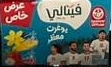
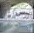
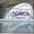
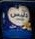
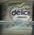
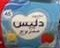
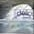
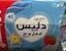
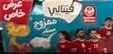
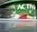
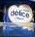
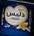
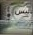
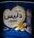
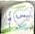
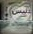
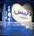
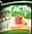
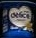
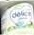
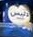
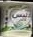
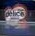
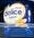
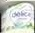
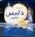
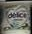
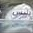
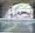
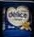
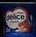
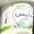
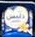
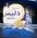
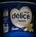
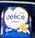
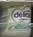
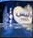
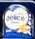
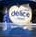
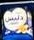
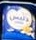
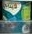
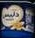
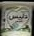
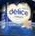
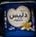
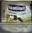
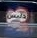
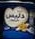
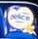
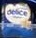
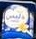
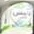
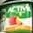
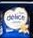
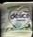
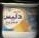
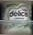
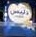
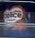
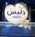
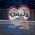
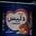
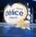
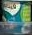
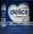
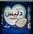
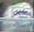
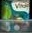
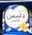
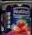
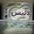
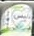
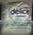
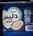
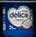
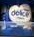
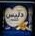
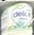
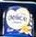
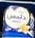
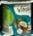
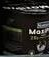
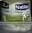
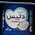
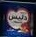
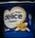
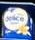
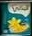
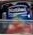
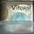
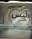
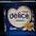
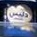
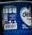
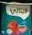
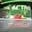
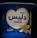
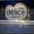
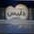
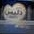
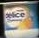
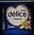
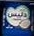
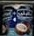
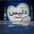
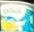
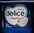
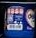
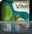
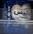
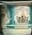
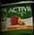
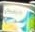
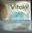
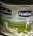
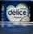
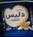
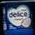
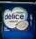
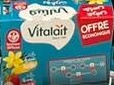
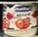
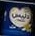
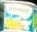
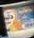
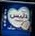
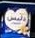
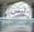
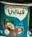
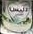
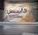
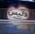
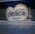
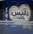
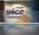
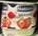
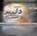
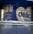
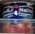
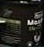
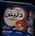
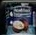
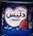
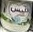
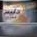
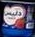
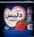
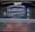
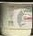
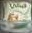
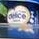
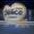
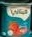
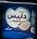
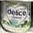
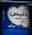
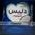
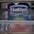
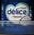
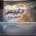
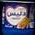
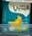
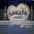
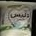
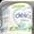
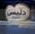
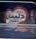
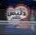
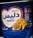
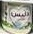
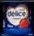
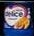
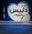
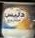
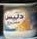
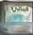
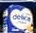
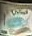
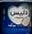
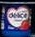
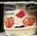
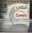
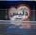
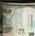
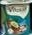
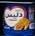
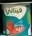
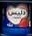
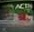
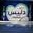
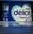
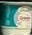
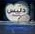
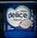
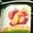
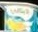
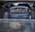
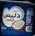
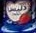
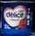
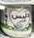
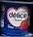
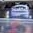
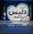
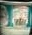
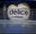
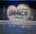
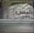
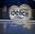
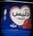
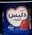
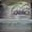
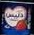
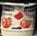
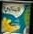
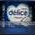
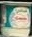
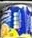
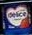
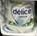
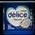
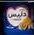
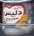
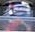
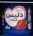
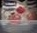
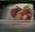
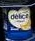
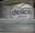
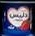
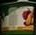
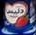
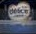
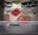
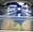
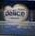
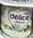
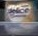
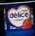
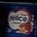
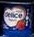
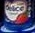
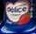
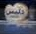
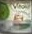
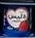
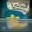
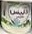
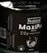
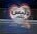
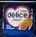
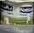
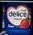
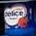
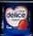
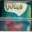
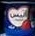
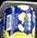
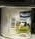
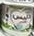
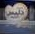
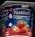
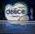
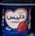
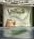
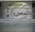
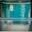
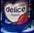
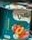
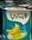
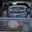
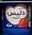
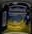
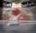
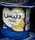
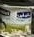
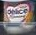
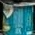
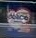
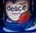
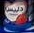
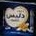
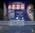
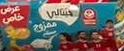
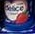
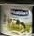
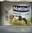
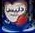
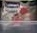
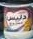
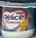
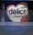
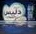
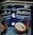
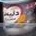
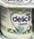
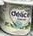
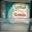
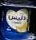
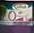
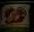
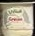
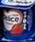
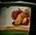
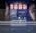
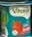
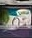
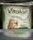
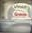
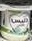
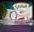
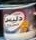
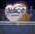
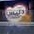
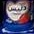
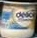
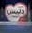
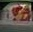
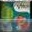
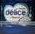
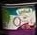
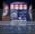
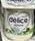
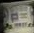
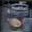
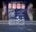
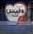
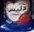
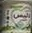
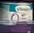
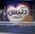
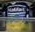
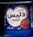
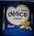
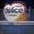
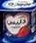
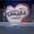
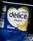
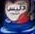
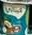
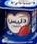
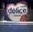
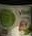
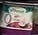
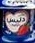
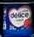
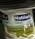
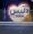
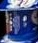
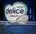
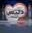
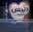
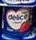
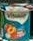
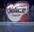
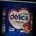
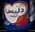
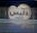
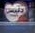
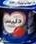
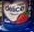
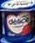
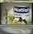
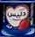
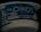
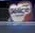
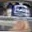
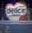
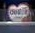
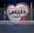
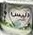
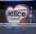
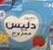
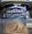
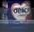
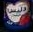
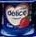
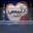
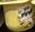
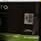
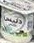
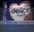
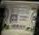
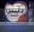
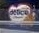
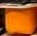
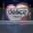
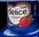
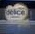
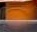
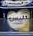
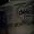
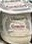
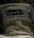
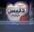
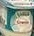
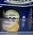
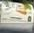
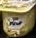
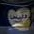
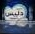
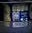
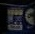
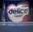
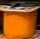
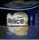
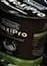
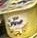
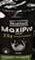

In [10]:
import glob
from IPython.display import HTML, display
import base64

def create_scrollable_grid(folder='/content/temp_crops', max_images=100):
    images = sorted(glob.glob(f"{folder}/*.jpg"))[:max_images]
    html_out = '<div style="display: flex; flex-wrap: wrap; height: 500px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;">'

    for img_path in images:
        name = os.path.basename(img_path)
        with open(img_path, "rb") as f:
            data = base64.b64encode(f.read()).decode("utf-8")

        html_out += f'''
            <div style="margin: 5px; text-align: center; border: 1px solid #eee;">
                <img src="data:image/jpeg;base64,{data}" style="width: 100px; height: 100px; object-fit: contain;"><br>
                <span style="font-size: 10px;">{name}</span>
            </div>'''

    html_out += '</div>'
    display(HTML(html_out))

# Show the first 150 crops
create_scrollable_grid(max_images=700)

### 📂 Automated Gallery Sorting
Run this cell to automatically move your chosen crop numbers into the Délice and Competitor folders.

In [11]:
import os
import shutil

def sort_crops_to_gallery(delice_nums, competitor_nums, source_folder='/content/temp_crops'):
    # Define and create target folders
    folders = ['/content/gallery_delice', '/content/gallery_competitors']
    for folder in folders:
        if os.path.exists(folder): shutil.rmtree(folder)
        os.makedirs(folder)

    # Helper to copy images
    def copy_list(nums, target):
        count = 0
        for n in nums:
            filename = f"crop_{n:03d}.jpg"
            src = os.path.join(source_folder, filename)
            if os.path.exists(src):
                shutil.copy(src, os.path.join(target, filename))
                count += 1
        return count

    d_count = copy_list(delice_nums, '/content/gallery_delice')
    c_count = copy_list(competitor_nums, '/content/gallery_competitors')

    print(f"✅ Successfully moved {d_count} images to gallery_delice")
    print(f"✅ Successfully moved {c_count} images to gallery_competitors")

# User provided numbers
delice_indices = [3, 4, 11, 9, 12, 37, 52, 82, 92, 103, 120, 176, 197, 200, 331, 333, 550]
competitor_indices = [69, 77, 91, 94, 99, 107, 123, 134, 136, 223, 262, 234, 264, 562, 583, 691]

sort_crops_to_gallery(delice_indices, competitor_indices)

✅ Successfully moved 17 images to gallery_delice
✅ Successfully moved 16 images to gallery_competitors


In [ ]:
import os
# Check what folders actually exist in /content
print("Current folders in /content:")
!ls -d /content/*/

Current folders in /content:
/content/drive/  /content/sample_data/	/content/temp_crops/


### Step 1: Install High-Precision Model Dependencies

In [12]:
# Step 1: Library Installation
# This cell only needs to be run once per session.
import sys
!{sys.executable} -m pip install sentence-transformers

### Step 2: Prepare your Folders
1. Click the **Folder icon** on the left sidebar.
2. Right-click and create two folders: `gallery_delice` and `gallery_competitors`.
3. Upload 5-10 images of your products to `gallery_delice`.
4. Upload 5-10 images of competitor products to `gallery_competitors`.
5. Ensure your full shelf image is uploaded as `shelf_photo.jpg`.

### Step 3: Run the Enterprise Analysis
This cell contains the logic for the CLIP-ViT-L-14 Contrastive model.

In [13]:
import torch
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sentence_transformers import SentenceTransformer, util
import torchvision
import torch.nn.functional as F

%matplotlib inline

def build_gallery_embeddings(folder_path, model):
    image_paths = glob.glob(f"{folder_path}/*.jpg") + glob.glob(f"{folder_path}/*.png")
    if not image_paths: return None
    embeddings = []
    for path in image_paths:
        img = Image.open(path).convert("RGB").resize((384, 384), Image.Resampling.LANCZOS)
        with torch.no_grad():
            emb = model.encode(img, convert_to_tensor=True, show_progress_bar=False)
            embeddings.append(F.normalize(emb, p=2, dim=-1))
    return torch.stack(embeddings)

def run_enterprise_shelf_analysis(shelf_image_path, yolo_weights_path):
    print("--- Stage 1: Initializing ViT-L-14 Embedder ---")
    model_embedder = SentenceTransformer('sentence-transformers/clip-ViT-L-14')
    delice_gallery = build_gallery_embeddings('/content/gallery_delice', model_embedder)
    comp_gallery = build_gallery_embeddings('/content/gallery_competitors', model_embedder)

    if delice_gallery is None or comp_gallery is None:
        print("ERROR: Gallery folders empty!"); return

    print("--- Stage 2: YOLO Detection ---")
    sku_model = torch.hub.load('ultralytics/yolov5', 'custom', path=yolo_weights_path, force_reload=False)
    sku_model.conf = 0.30
    results = sku_model(shelf_image_path, size=1280)
    detections = results.xyxy[0].cpu().numpy()

    full_image = cv2.imread(shelf_image_path)
    vis_image = full_image.copy()
    proposals = detections[:, :4]
    scores = detections[:, 4]
    keep_indices = torchvision.ops.nms(torch.tensor(proposals), torch.tensor(scores), 0.15)

    print(f"--- Stage 3: Contrastive Scoring ({len(keep_indices)} items) ---")
    for i in keep_indices:
        box = np.array(proposals[i]).astype(int)
        crop = full_image[box[1]:box[3], box[0]:box[2]]
        if crop.size < 500: continue

        crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).resize((384, 384), Image.Resampling.LANCZOS)
        with torch.no_grad():
            emb = F.normalize(model_embedder.encode(crop_pil, convert_to_tensor=True, show_progress_bar=False), p=2, dim=-1)

        score_delice = torch.max(util.cos_sim(emb, delice_gallery)).item()
        score_comp = torch.max(util.cos_sim(emb, comp_gallery)).item()

        is_delice = (score_delice > score_comp + 0.02) and (score_delice > 0.60)
        color = (0, 255, 0) if is_delice else (0, 0, 255)
        cv2.rectangle(vis_image, (box[0], box[1]), (box[2], box[3]), color, 3)

    plt.figure(figsize=(12, 8)); plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

--- Stage 1: Initializing ViT-L-14 Embedder ---


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2026-7-10 Python-3.12.13 torch-2.11.0+cpu CPU



--- Stage 2: YOLO Detection ---


Fusing layers... 
YOLOv5x summary: 322 layers, 86173414 parameters, 0 gradients, 203.8 GFLOPs
Adding AutoShape... 


--- Stage 3: Contrastive Scoring (722 items) ---


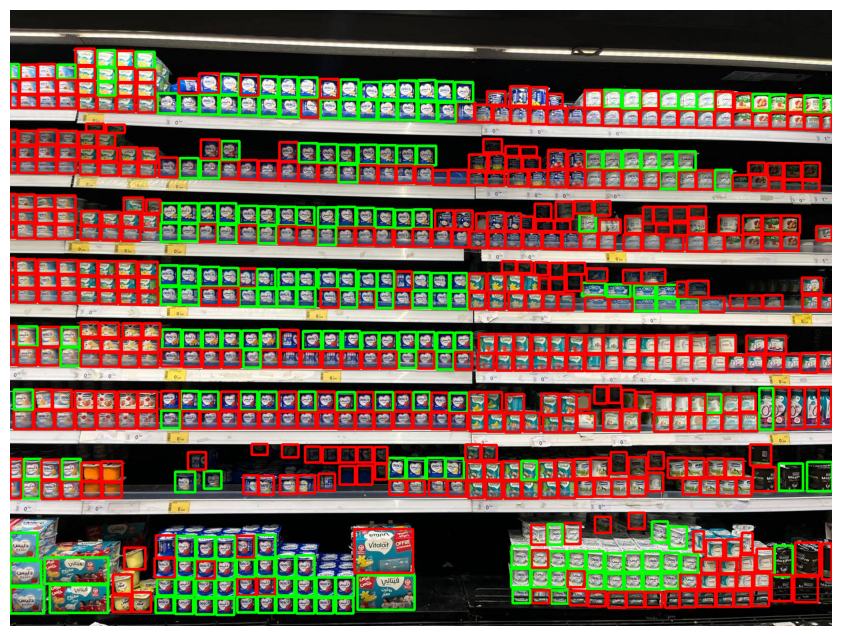

In [14]:
# FINAL EXECUTION
run_enterprise_shelf_analysis('/content/shelf_photo.jpg', '/content/best.pt')